**Bài tập 1: Dự báo chuỗi thời gian đa biến**



   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


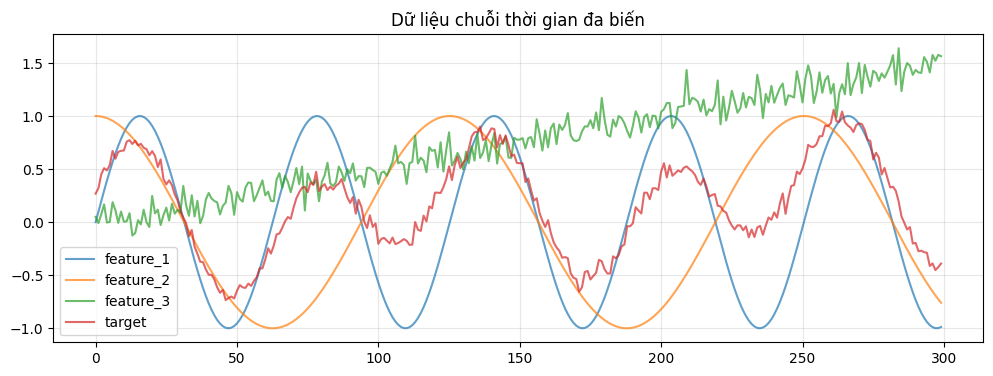

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})
print(df.head())

plt.figure(figsize=(12, 4))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu chuỗi thời gian đa biến')
plt.show()


Phần A — tiền xử lý

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train_df = df[:train_size]
val_df = df[train_size:train_size + val_size]
test_df = df[train_size + val_size:]

In [ ]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Fit trên train
feature_scaler.fit(train_df[['feature_1', 'feature_2', 'feature_3']])
target_scaler.fit(train_df[['target']])

# Transform
X_train_scaled = feature_scaler.transform(
    train_df[['feature_1', 'feature_2', 'feature_3']]
)

X_val_scaled = feature_scaler.transform(
    val_df[['feature_1', 'feature_2', 'feature_3']]
)

X_test_scaled = feature_scaler.transform(
    test_df[['feature_1', 'feature_2', 'feature_3']]
)

y_train_scaled = target_scaler.transform(train_df[['target']])
y_val_scaled = target_scaler.transform(val_df[['target']])
y_test_scaled = target_scaler.transform(test_df[['target']])

Phần B — định nghĩa và train mô hình
     

Phần C — đánh giá trên tập test

Phần D — phân tích nâng cao